## Setup

Runs on Colab, no-op locally. Run it first, before anything else.

`torch` and `numpy` are deliberately left alone: Colab's builds are CUDA-matched, and replacing them costs minutes and forces a runtime restart.

In [ ]:
# --- Colab setup ---------------------------------------------------
# Installs only what Colab is missing. Locally this whole cell is skipped.
import subprocess, sys

try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "transformers==5.7.0",
            "umap-learn>=0.5.12",
            "plotly>=6.9.0",
        ],
        check=True,
    )
    print("Colab: dependencies installed.")
else:
    print("Local environment: nothing to install.")


# A2 What embeddings captures

Notebook A1 treated the LLM as a _box_ that fills in blanks. Here we look at the
representations and the internals.


By the end you should be able to:

1. Read a token's **static** embedding out of the model and measure similarity between words.
2. Build a **semantic axis** from anchor words, project a vocabulary onto it, and test the
   result against a control that could falsify it.
3. Show that a token's **contextual** representation depends on the sentence around it.
4. Explain why the *last* layer is usually the wrong place to tap for a downstream task.

In [ ]:
from transformers import AutoTokenizer, AutoModelForMaskedLM
import torch
import re

model_id = "answerdotai/ModernBERT-base"

tokenizer = AutoTokenizer.from_pretrained(model_id)
# We never use the masked-LM head in this notebook, only the embedding table and the
# hidden states. `AutoModel` works too; this keeps the load identical to notebook A1.
model = AutoModelForMaskedLM.from_pretrained(model_id).eval()

A trained LLM carries two quite different kinds of representation:

- The **input embedding table** is a lookup: one fixed vector per vocabulary entry, identical
  every time that token appears. It is the closest thing inside a transformer to a word2vec
  vector. Sections 1 and 2.
- The **hidden states** are what the encoder produces after the input went through the encoder blocks (e.g., attention). The same token gets a different vector in every sentence. Section 3.

Sections 1 and 2 ask how much a lookup table alone knows. Section 3 shows what context adds.

In [ ]:
model

## 1. Static embeddings

`get_input_embeddings()` returns the lookup table itself: one row per vocabulary entry. For
ModernBERT that is a `50,368 x 768` matrix: every token the model can read, as a point in
768-dimensional space.

Nothing here has seen a sentence. This is where the model starts, before any attention.

To get 50,368 points onto a screen we need a projection. UMAP maps them to 2-D while trying
to keep near neighbours near.

> **Two warnings.** The fit takes ~30 s on a laptop and a few minutes on Colab's CPU. And the
> output is not comparable across machines: `random_state` fixes the seed, not the
> `umap-learn`, `numba` and BLAS versions. Your picture will not be pixel-identical to your
> neighbour's. `PaCMAP` is a reasonable alternative with the same caveat.

In [ ]:
emb = model.get_input_embeddings()  # Embedding(50368, 768)
W = emb.weight.detach()  # (vocab_size, 768)

In [ ]:
token2id = tokenizer.get_vocab()
id2token = {v: k for k, v in token2id.items()}

In [ ]:
from umap import UMAP

# from pacmap import PaCMAP
from matplotlib import pyplot as plt
import plotly.express as px
import pandas as pd

In [ ]:
projector = UMAP(n_components=2, metric="cosine", random_state=202609)
# projector = PaCMAP(n_components=2)
W_prj = projector.fit_transform(W)  # (vocab_size, 2)
# this might take couple of minutes depending on your machine

In [ ]:
# 2. Structure data with metadata for the hover tooltip
df = pd.DataFrame(
    {
        "x": W_prj[:, 0],
        "y": W_prj[:, 1],
        "text": [
            id2token[i] for i in range(W_prj.shape[0])
        ],  # What you see when hovering
    }
)
df.sample(5)  # Show a few rows of the data frame

In [ ]:
fig = px.scatter(
    df,
    x="x",
    y="y",
    hover_data=["text"],
    width=800,
    height=800,
    title="Interactive Embedding Space",
)

# Set the uniform size of all markers (e.g., 12 pixels)
fig.update_traces(marker=dict(size=1))
fig.show()

# Or simple matplotlib
# fig = plt.figure(figsize=(12, 12))
# plt.scatter(W_prj[:, 0], W_prj[:, 1], s=0.5)

**Question**: What do you see? Feel free to zoom in and move around.

<details>
<summary><b>Hints</b></summary>
1. Some of the clusters hold quite specific tokens (like numbers)
2. The upper part of the biggest cloud contains words related to education/learning.
</details>

### Let's zoom in
Zoom in. Anchor the window to a token rather than hardcoding coordinates. `UMAP` output
is not comparable across machines, so fixed limits can land on empty space.

In [ ]:
df["leading_space"] = df["text"].str.startswith("Ġ")
df_filtered = df[df["leading_space"]]

SEED = "Ġhospital"  # try Ġemployment, Ġmarried, Ġincome
K = 600  # how many neighbours to show

cx, cy = df.loc[df["text"] == SEED, ["x", "y"]].iloc[0]
d2 = (df_filtered["x"] - cx) ** 2 + (df_filtered["y"] - cy) ** 2
near = df_filtered.loc[d2.nsmallest(K).index]

fig = px.scatter(
    near,
    x="x",
    y="y",
    hover_data=["text"],
    width=800,
    height=800,
    title=f"The {K} tokens nearest {SEED} in the projection",
)
fig.update_traces(marker=dict(size=4))
fig.show()


### Embeddings and Word Similarities

In [ ]:
# Similarities
def vec(word: str) -> torch.Tensor:
    """Look up the static token embedding for a given word.

    If the word splits into several tokens, the pieces are averaged.

    Args:
        word: The word to look up. A leading space is added if missing.
    Returns:
        The static token embedding for the given word.
    """
    if not word.startswith(" "):
        word = " " + word  # add space for the first token
    ids = tokenizer(word, add_special_tokens=False)["input_ids"]
    # print(tokenizer.tokenize(word)) # sanity check
    return W[ids].mean(0)  # average if the word splits into pieces

In [ ]:
def similarity_fn(word1: str, word2: str) -> float:
    """Compute the cosine similarity between the static token embeddings of two words.

    Args:
        word1: str
        word2: str
    Returns:
        float: The cosine similarity between the embeddings of the two words.
    """
    v1 = vec(word1)
    v2 = vec(word2)
    with torch.no_grad():
        return torch.cosine_similarity(v1, v2, dim=0).item()

In [ ]:
similarity_fn("cat", " dog")

In [ ]:
print(similarity_fn("king", "queen"))
print(similarity_fn("doctor", "nurse"))
print(similarity_fn("employed", "unemployed"))
print(similarity_fn("king", "employment"))

### Before moving on

**Questions:**
- These vectors are a lookup table: one vector per token, whatever the sentence. 
  - What can a representation like that *not* express?
- `employed` and `unemployed` score **0.35**, and `king`/`queen` only **0.57**. Antonyms turn
  up in near-identical contexts, so distributional methods place them close together. 
  - Is cosine similarity here measuring meaning, or something else?

## 2. Semantic projection: building a ruler out of anchor words

Cosine similarity compares two words at a time. 
**Semantic projection** does something more useful for social science: define a *direction* from two sets of anchor words, then score a whole vocabulary along it.

Average a set of clearly healthy words, average a set of clearly unhealthy ones, subtract.
The result is a ruler. Project any token onto it and you get a number.

This is the method behind [Grand et al. (2022)](https://www.nature.com/articles/s41562-022-01316-8),
and, in its best-known social-science application,
[Garg et al. (2018)](https://www.pnas.org/doi/10.1073/pnas.1720347115), who tracked a century
of gender and ethnic stereotypes by projecting occupation words in embeddings trained on
successive decades of text. Note what is being measured: **the corpus, not the world.**

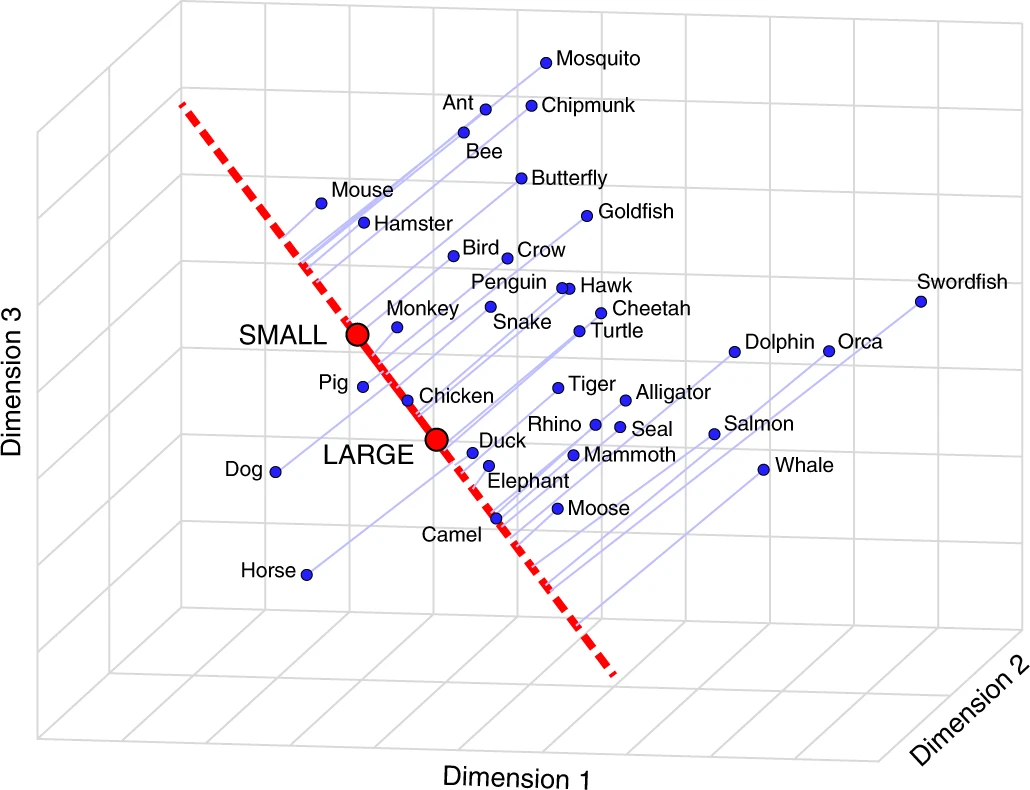
*Schematic illustration of semantic projection (figure from [Grand et al. (2022)](https://www.nature.com/articles/s41562-022-01316-8)).*

In [ ]:
import pandas as pd


def semantic_axis(pole_a: list[str], pole_b: list[str]) -> torch.Tensor:
    """A direction in embedding space: mean of one pole minus mean of the other."""
    a = torch.stack([vec(w) for w in pole_a]).mean(0)
    b = torch.stack([vec(w) for w in pole_b]).mean(0)
    d = a - b
    return d / d.norm()


def project(words: list[str], axis: torch.Tensor) -> pd.Series:
    """Cosine of each word with the axis. Positive = pole A end, negative = pole B end."""
    scores = {w: torch.cosine_similarity(vec(w), axis, dim=0).item() for w in words}
    return pd.Series(scores, name="projection").sort_values(ascending=False)


In [ ]:
HEALTHY = ["healthy", "fit", "wellness", "recovery"]
UNHEALTHY = ["illness", "disease", "sick", "hospitalised"]

HEALTH_TOKENS = [
    "nutrition",
    "screening",
    "exercise",
    "obesity",
    "alcohol",
    "therapy",
    "smoking",
    "vaccination",
    "depression",
    "diabetes",
    "asthma",
    "cancer",
]

health_axis = semantic_axis(HEALTHY, UNHEALTHY)
health_scores = project(HEALTH_TOKENS, health_axis)
print(health_scores.round(3).to_string())

### What is this axis actually measuring?

The ordering is clearly not random. `nutrition`, `screening` and `exercise` at the top;
`cancer`, `asthma` and `diabetes` at the bottom. That looks like "healthy vs sick", and it is
tempting to stop reading there. 

**Questions**: What is the issue here? Hint: look at `vaccination`.

<details>
<summary><b>Answer</b>
</summary>

Look at `vaccination`. It sits down with the diagnoses, next to `depression` and `smoking`,
and vaccination is about as health-promoting as a token gets. Meanwhile `screening`, also a
clinical procedure, sits near the top.

A better description of this direction is **lay wellness vocabulary vs clinical vocabulary**.
The anchors we picked (`healthy`, `fit`, `wellness` against `illness`, `disease`) are exactly
the words that separate those two registers, so that is the direction we built. *The axis
measures what the anchors measure, not what we named it.*

Notebook A3 walks into the same wall from a different direction: a probe that scores 0.70 on
"is this statement true" turns out to have learned "does this pair look plausible".
</details>



### The control that decides it

Before believing any of that, ask what an axis with **no** meaning would produce.

The obvious control (**project onto random directions in 768-space**) is not good enough.
Embedding vectors do not fill their space; they occupy a narrow cone
([Ethayarajh, 2019](https://arxiv.org/abs/1909.00512)). A direction built by subtracting two
real word vectors lies inside that cone and will spread projections further than an isotropic
random direction, *whatever* words you build it from. Comparing against isotropic noise
measures the cone, not the semantics.

The **matched** control builds its axis exactly the way we did (average four words, subtract
the average of four others), but draws words at random from the vocabulary. The cone
effect is now present in both arms, so only the semantics differ.

The computation for the **matched control** is provided below.

In [ ]:
# Ordinary lowercase words, so random poles are comparable to hand-picked ones.
WORD_POOL = sorted(
    t[1:] for t in tokenizer.get_vocab() if re.fullmatch(r"Ġ[a-z]{4,10}", t)
)
print(f"{len(WORD_POOL):,} single-token words available for random poles")


def matched_null(words: list[str], n: int = 200, seed: int = 0) -> torch.Tensor:
    """The same measurement, for `n` axes built from RANDOM anchor words.

    Each null axis is built by the exact recipe `semantic_axis` uses for a real one
    (average 4 words, subtract the average of 4 others), except that all 8 words are
    drawn at random from the vocabulary instead of being chosen to mean something.

    So a null axis sits in the same narrow cone as `health_axis` does, and the only
    thing it is missing is the semantics. That is what makes it the honest comparison:
    if the health axis spreads these tokens no further than these random axes do, its
    ordering came from the geometry and not from meaning.
    """
    g = torch.Generator().manual_seed(seed)
    out = []
    for _ in range(n):
        pick = [WORD_POOL[i] for i in torch.randperm(len(WORD_POOL), generator=g)[:8]]
        out.append(project(words, semantic_axis(pick[:4], pick[4:])).std())
    return torch.tensor(out)


def report(name: str, scores: pd.Series, words: list[str]) -> None:
    """Effect size of an axis against the matched null, in standard deviations (z)."""
    spread = scores.std()
    print(f"{name}: spread of projections = {spread:.3f}")
    for label, null in [
        ("matched_control", matched_null(words)),
    ]:
        z = (spread - null.mean()) / null.std()
        print(
            f"   vs {label} null {null.mean():.3f} +/- {null.std():.3f}   z = {z:>4.1f}"
        )


report("health", health_scores, HEALTH_TOKENS)

**Question**: Why do we look at the spread (standard deviation)?

<details>
<summary><b>Hint</b></summary>

1. Spread (standard deviation) above the null distribution means "**this direction separates these twelve words more than a meaningless direction would**." 
2. Raw spread on its own says nothing: 0.078 is meaningless until you know the matched null sits at 0.042 ± 0.012.

Issues:
1. It's a property of the axis and your chosen token list. 
2. Adding one distant token inflates it hard. Taking the published health scores and appending a single hypothetical token at −0.3 takes z from 3.0 to 5.1; at −0.40, to 6.9. 
3. High spread can't distinguish "good axis" from "axis that happens to scatter these words".
</details>

### Your turn

The cell below is prefilled with a socioeconomic axis so it runs as-is. **Replace the three
lists with an axis of your own** and see whether it survives the matched control.

Keep to single-token words where you can. `vec()` averages the pieces of a word that splits,
and the average of two subword vectors is not the word.

In [ ]:
# ---- replace these three lists ------------------------------------------------
MY_POLE_A = ["wealthy", "affluent", "privileged", "educated"]
MY_POLE_B = ["poor", "deprived", "disadvantaged", "unemployed"]
MY_TOKENS = [
    "university",
    "inheritance",
    "investment",
    "savings",
    "pension",
    "mortgage",
    "debt",
    "welfare",
    "eviction",
    "bankruptcy",
    "homeless",
    "foodbank",
]
# -------------------------------------------------------------------------------

my_axis = semantic_axis(MY_POLE_A, MY_POLE_B)
my_scores = project(MY_TOKENS, my_axis)
print(my_scores.round(3).to_string())
print()
report("my axis", my_scores, MY_TOKENS)

## 3. Contextualised embeddings

Everything so far used one fixed vector per token. Now we run sentences through the encoder
and take the vectors it produces: **where the same token can come out differently depending on
what surrounds it.**

**Task:** We look at how the cosine similarity of tokens changes as they flow through the encoder.

In [ ]:
# Three senses of the SAME token. Every "apple" below is:
#   singular      : "apples" is a different token (Ġapples)
#   lowercase     : "Apple" is a different token (ĠApple)
#   mid-sentence  : so it always carries the leading space: Ġapple
# Those three rules are what make the layer-0 baseline come out at exactly 1.0.
fruit = [
    "I ate a red apple with my lunch and the juice ran down my chin.",
    "She sliced the apple into thin wedges and arranged them on a plate.",
    "He bought a crisp apple from the fruit stall on the corner.",
    "He packed a cheese sandwich, an apple and a carton of juice for school.",
]
company = [
    "Journalists reported that apple will launch a new phone in September.",
    "Analysts expect apple to report record quarterly revenue.",
    "The antitrust lawsuit against apple reached the Supreme Court.",
    "She left her job at apple to join a smaller software startup.",
]
city = [
    "Driving a car in the Big apple is very hard.",
    "Jazz musicians in the 1930s loved playing gigs in the Big apple.",
    "Their family took a fun weekend trip to the Big apple for the holidays.",
    "I am flying to the Big apple for a meeting next week.",
]

SENSES = {"fruit": fruit, "company": company, "city": city}

# One sentence, three occurrences of the identical token, three different senses.
statement = (
    "When I packed for the trip to the Big apple, I made sure to bring "
    "a red apple and my laptop from apple."
)
EXPECTED = ["city", "fruit", "company"]  # in order of appearance

In [ ]:
def find_ids(input_text: str, word: str, occurrence: int = 0) -> list[int]:
    """Token positions covering `word`. Returns a list, since a word may be several tokens."""
    spans = [m.span() for m in re.finditer(rf"\b{re.escape(word)}\b", input_text)]
    if not spans:
        raise ValueError(f"{word!r} not found in {input_text!r}")
    a, b = spans[occurrence]
    offsets = tokenizer(input_text, return_offsets_mapping=True)["offset_mapping"]
    # e > s drops special tokens, which carry the empty span (0, 0)
    return [i for i, (s, e) in enumerate(offsets) if e > s and s < b and e > a]


def embed(
    input_text: str, word: str, layer: int = -1, occurrence: int = 0
) -> torch.Tensor:
    """That word's contextual vector: mean over its subword pieces."""
    idx = find_ids(input_text, word, occurrence)
    enc = tokenizer(input_text, return_tensors="pt")
    with torch.no_grad():
        out = model(**enc, output_hidden_states=True)
    return out.hidden_states[layer][0, idx].mean(dim=0)


In [ ]:
# The whole demo rests on these all being the SAME token. Check it, don't hope.
for text in [s for sents in SENSES.values() for s in sents] + [statement]:
    ids = tokenizer(text)["input_ids"]
    for k in range(len(re.findall(r"\bapple\b", text))):
        pieces = [
            tokenizer.convert_ids_to_tokens(ids)[i]
            for i in find_ids(text, "apple", occurrence=k)
        ]
        assert pieces == ["Ġapple"], f"{pieces} in {text!r}"

print("every apple in every sentence is exactly ['Ġapple']")

In [ ]:
def prototype(sentences: list[str], layer: int) -> torch.Tensor:
    """The average 'apple' vector for one sense, at one layer."""
    return torch.stack([embed(s, "apple", layer=layer) for s in sentences]).mean(0)


def sense_table(text: str, layer: int) -> pd.DataFrame:
    """cos(each apple in `text`, each sense prototype). One row per occurrence."""
    protos = {name: prototype(sents, layer) for name, sents in SENSES.items()}
    rows = [
        [
            torch.cosine_similarity(
                embed(text, "apple", layer=layer, occurrence=k), p, dim=0
            ).item()
            for p in protos.values()
        ]
        for k in range(len(EXPECTED))
    ]
    return pd.DataFrame(
        rows,
        columns=list(protos),
        index=[f"apple #{k + 1} ({EXPECTED[k]})" for k in range(len(EXPECTED))],
    )

### (Layer 0) the same token, three times

`statement` contains `apple` three times, and we just proved all three are the
*identical* token `Ġapple`. So before any attention has run, there is nothing to
tell them apart, and the table below should be all `1.000`.

That is the baseline the rest of this section is measured against.

In [ ]:
# Layer 0 is the embedding lookup: no attention has run yet.
table_0 = sense_table(statement, layer=0)
display(table_0.round(3))
print("closest sense per apple:", list(table_0.idxmax(axis=1)))
print("expected            :", EXPECTED)

### (Layer 10) Context kicks in

Same three tokens, same code, ten layers of attention later. Each `apple` should
now be closest to *its own* sense.

In [ ]:
table_10 = sense_table(statement, layer=10)

predicted = list(table_10.idxmax(axis=1))
print("Raw cosine similarities")
display(table_10.round(3))


### (The output layer) 

`layer=-1` is the final layer: the "output embeddings", and the thing you would
reach for by default.

Same table, same code, one layer further on. This time the reading we have been
using breaks: every apple comes out closest to `fruit`.

The senses have not gone anywhere. 

**Quick fix**: Put each column on the same scale first (subtract its mean, divide by its
standard deviation) and the same reading is correct again.

In [ ]:
table_out = sense_table(statement, layer=-1)
display(table_out.round(3))

print("row-wise (per apple) :", list(table_out.idxmax(axis=1)), "  <- all fruit")

# standardise each column, then read the rows again
z = (table_out - table_out.mean(axis=0)) / table_out.std(axis=0)
display(z.round(2))

predicted = list(z.idxmax(axis=1))
print("column-standardised  :", predicted)
print("expected             :", EXPECTED)
print(f"correct: {sum(p == e for p, e in zip(predicted, EXPECTED))}/3")

### Your Turn

1. Pick a word that has multiple meanings,
2. Write SENSES for each meaning (list of example statements that correspond to a specific meaning of a word), 
3. Come up with a `statement` that uses the word multiple times
4. Compute how the embeddings of these words change over **all** the layers


### ✏️ Your turn

1. Pick a word that has more than one meaning.
2. Fill in `MY_SENSES`: a few example sentences per meaning.
3. Write `MY_STATEMENT`: one sentence that uses the word once for each meaning.
4. Run the sweep and find the layers where the senses actually separate.

**Three rules when picking your word**, or the layer-0 baseline will not be 1.000 and you
are measuring against the wrong starting point:

- **singular**: `springs` is a different token from `spring`
- **lowercase**: `Spring` is a different token again
- **never the first word of a sentence**, so it always carries its leading space

The cell checks this for you and stops with a message if your occurrences do not tokenise
identically.

<details>
<summary><b>(Help)</b> If you do not want to come up with the example</summary>

1. I chose to work with `spring` (`MY_WORD`)
2. Here are the senses:

```
    "season": [
        "The garden comes alive in spring when the first bulbs appear.",
        "We usually travel in spring because the weather is mild.",
        "Every spring the swallows return to the same barn.",
        "She was born one warm morning in spring.",
    ],
    "water": [
        "They filled their bottles at a natural spring in the hills.",
        "The village well is fed by an underground spring.",
        "Hikers stopped to drink from a cold mountain spring.",
        "A thermal spring bubbles up beside the old stone path.",
    ],
    "coil": [
        "The mattress sagged because a metal spring had snapped.",
        "He wound the spring tightly before releasing the mechanism.",
        "A broken spring made the old clock stop overnight.",
        "The pen clicked because a tiny spring pushed the tip out.",
    ],
```
3. Here is the statement:
```
MY_STATEMENT = ("Early one spring we hiked up to a mountain spring, and I noticed "
    "on the way back that my watch had a broken spring.")
MY_EXPECTED = ["season", "water", "coil"] 
```
</details>

In [ ]:
# ---- replace these four -----------------------------------------------------------
MY_WORD = ""

MY_SENSES = {
    "...": [
        "...",
        "...",
        "...",
        "..",
    ],
    "...": [...],
    "...": [...],
}

MY_STATEMENT = ...
MY_EXPECTED = ["...", "...", "..."]  # the sense of each occurrence, in order
# -----------------------------------------------------------------------------------

# Every occurrence must be the identical token, see the three rules above.
_ids = tokenizer(MY_STATEMENT)["input_ids"]
_seen = {
    tuple(_ids[i] for i in find_ids(MY_STATEMENT, MY_WORD, k))
    for k in range(len(MY_EXPECTED))
}
assert len(_seen) == 1, (
    f"the occurrences of {MY_WORD!r} do not tokenise identically: {_seen}. "
    "Check for capitals, plurals, or a sentence-initial use."
)


def embed_all_layers(text: str, word: str, occurrence: int = 0) -> torch.Tensor:
    """That word's vector at EVERY layer, from ONE forward pass. Shape (n_layers, hidden)."""
    idx = find_ids(text, word, occurrence)
    with torch.no_grad():
        out = model(**tokenizer(text, return_tensors="pt"), output_hidden_states=True)
    return torch.stack([h[0, idx].mean(dim=0) for h in out.hidden_states])


def sense_sweep(
    word: str,
    senses: dict[str, list[str]],
    statement: str,
    expected: list[str],
    layers: list[int] = [0, 4, 10, 12, -1],
) -> pd.DataFrame:
    """Both readings from section 3, at each requested layer. 15 forward passes, not 345."""
    protos = {
        name: torch.stack([embed_all_layers(s, word) for s in sents]).mean(0)
        for name, sents in senses.items()
    }
    occurrences = [
        embed_all_layers(statement, word, occurrence=k) for k in range(len(expected))
    ]

    rows = []
    for layer in layers:
        table = pd.DataFrame(
            [
                [
                    torch.cosine_similarity(v[layer], p[layer], dim=0).item()
                    for p in protos.values()
                ]
                for v in occurrences
            ],
            columns=list(protos),
        )
        # At layer 0 every prototype is the same static vector, so the columns have no
        # variance at all. Guard the divide; the row-wise reading still works there.
        spread = table.std(axis=0).replace(0.0, 1.0)
        z = (table - table.mean(axis=0)) / spread

        # DISPLAY
        display(z.round(2))
        rows.append(
            {
                "layer": layer,
                "raw": sum(a == b for a, b in zip(table.idxmax(axis=1), expected)),
                "standardised": sum(a == b for a, b in zip(z.idxmax(axis=1), expected)),
                "mean cos": round(table.values.mean(), 3),
            }
        )
    return pd.DataFrame(rows).set_index("layer")


layers_to_sweep_over = [0, 4, 10, 12, -1]  # YOU CAN ADD MORE LAYERS HERE

sweep = sense_sweep(
    MY_WORD, MY_SENSES, MY_STATEMENT, MY_EXPECTED, layers=layers_to_sweep_over
)
print(
    f"{MY_WORD!r}: how many of {len(MY_EXPECTED)} occurrences land on the right sense\n"
)
print(sweep.to_string())


## 4. What to take away

1. **A static embedding is a lookup table.** One vector per token, no matter the sentence.
   It carries some structure, but far less than a projection plot suggests.
2. **Semantic projection turns anchor words into a measuring instrument.** The instrument
   measures whatever separates the anchors, which is often not what you named it.
3. **Context does the work the static lookup cannot.** The identical token `Ġapple` splits
   cleanly into three senses by layer 10.

### (Optional) Going further

- [Grand et al. (2022), *Semantic projection recovers rich human knowledge of multiple object
  features from word embeddings*](https://www.nature.com/articles/s41562-022-01316-8)
- [Garg et al. (2018), *Word embeddings quantify 100 years of gender and ethnic
  stereotypes*](https://www.pnas.org/doi/10.1073/pnas.1720347115)
- [Ethayarajh (2019), *How contextual are contextualized word representations?*](https://arxiv.org/abs/1909.00512)
- [Bolukbasi et al. (2016), *Man is to computer programmer as woman is to
  homemaker?*](https://arxiv.org/abs/1607.06520)